# Bearing Order-Analysis Demo with Fixed BRF-Neuron Bank
Author: ChatGPT  Generated: 2025-06-13 14:12

This notebook shows a **classical envelope-order spectrum** workflow side-by-side with a **bank of balanced resonate-and-fire (BRF) neurons** whose natural frequencies are preset to the same mechanical orders.

Steps
1. Load example vibration trace (CSV).
2. Detect best resonance band with *spectral kurtosis*, then demodulate (Hilbert envelope).
3. Plot envelope order spectrum (baseline).
4. Build deterministic BRF neuron bank, feed the *band-passed* signal, collect spike-rates.
5. Plot spike-rate order spectrum and compare.

⚠️ **Prerequisites**
* `numpy`,`scipy`,`matplotlib`,`pandas`
* `brf_lightning` ≥ 0.1.0 (or adapt the BRF cell)

Adjust paths & parameters to your dataset as needed.

In [2]:

import numpy as np, pandas as pd, matplotlib.pyplot as plt, scipy.signal as sig, math, itertools, pathlib, re
from pathlib import Path
plt.rcParams['figure.dpi'] = 110

from brf_lightning.data.bearing.utils import load_vibration_data


In [3]:

# ── USER PARAMETERS ──────────────────────────────────────────────
DATA_FILE   = Path('data/bearing_thl_v1/fAII30.csv')   # <-- change
SHAFT_HZ    = 30.0                                    # shaft speed
ORDERS_OF_INTEREST = [3, 6, 9]                        # fault orders
FS_OVERRIDE = None                                    # set if CSV has no header


signal len = 4792320   fs = 8192.0


Text(0.5, 0, 's')

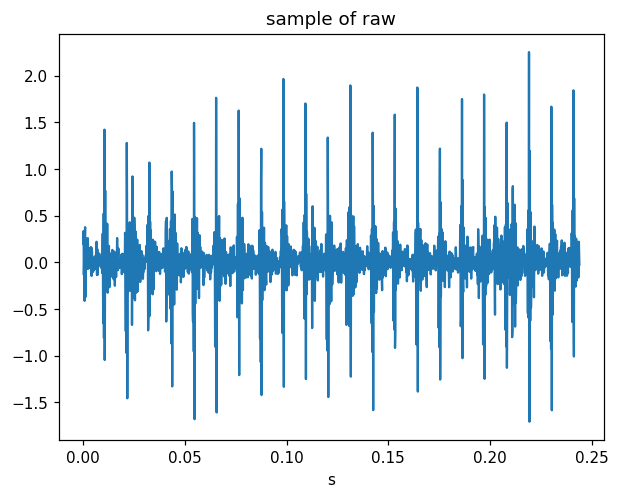

In [4]:

df, fs = load_vibration_data(DATA_FILE)
x_raw = df['sensor_bearing'].values
print('signal len =', len(x_raw), '  fs =', fs)
t = np.arange(len(x_raw))/fs
plt.plot(t[:2000], x_raw[:2000]); plt.title('sample of raw'); plt.xlabel('s')


selected band: 1270.0–3269.0 Hz


Text(0.5, 0, 'Hz')

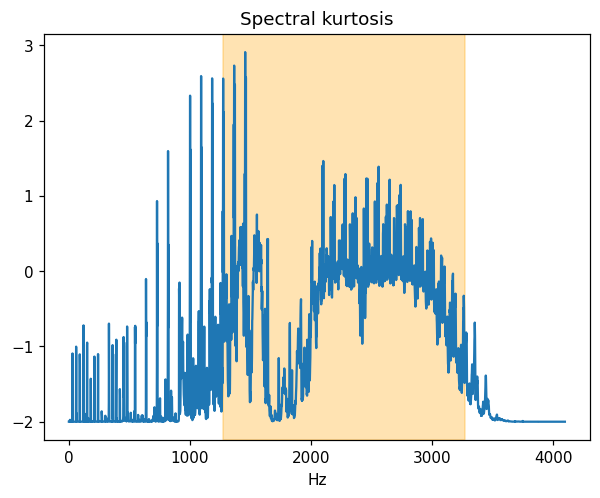

In [5]:

from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band
NPERSEG_STFT = 8192
MIN_FREQ, BANDWIDTH = 100.0, 2000.0
f, sk = spectral_kurtosis(x_raw, fs, nperseg=NPERSEG_STFT)
f_lo,f_hi = max_sk_band(f, sk, bandwidth=BANDWIDTH, min_freq=MIN_FREQ)
print(f'selected band: {f_lo:.1f}–{f_hi:.1f} Hz')
plt.figure(); plt.plot(f, sk); plt.axvspan(f_lo,f_hi, color='orange', alpha=.3)
plt.title('Spectral kurtosis'); plt.xlabel('Hz')

Text(0.5, 0, 'Order')

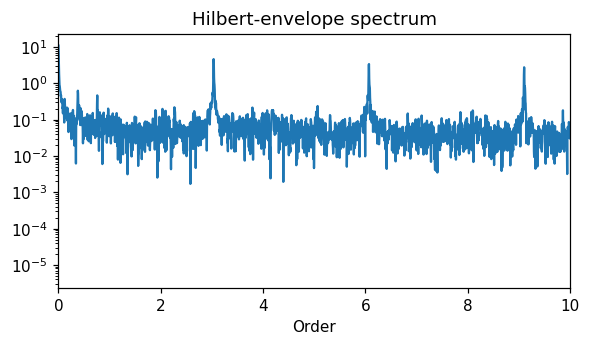

In [6]:

nyq=0.5*fs
sos = sig.butter(4,[f_lo/nyq,f_hi/nyq],'band',output='sos')
x_f = sig.sosfiltfilt(sos, x_raw)
env = np.abs(sig.hilbert(x_f))
# order spectrum
NFFT_ENV=65536
spec=np.fft.rfft(env*np.hanning(len(env)), n=NFFT_ENV)
freq=np.fft.rfftfreq(NFFT_ENV, d=1/fs)
orders=freq/ SHAFT_HZ
plt.figure(figsize=(6,3))
plt.semilogy(orders, np.abs(spec)); plt.xlim(0,10)
plt.title('Hilbert-envelope spectrum'); plt.xlabel('Order')


In [7]:

# ── Minimal fixed-parameter BRF implementation ──────────────────
class BRF:
    def __init__(self, omega, b=-1.0, fs=1.0, thresh=1.0):
        self.dt=1/fs; self.omega=omega*2*math.pi  # rad/s
        self.b=b; self.th=thresh; self.u=0+0j
        self.spikes=[]
    def step(self, I):
        self.u += self.dt*((self.b+1j*self.omega)*self.u + I)
        if self.u.real>self.th:
            self.spikes.append(1); self.u*=0
        else:
            self.spikes.append(0)
# neuron bank
neurons=[BRF(order*SHAFT_HZ) for order in ORDERS_OF_INTEREST]
for samp in x_f:                # excitation is band-passed vibration
    for n in neurons: n.step(samp)
spike_trains=np.array([n.spikes for n in neurons])
rates= spike_trains.mean(axis=1)      # crude rate
print('mean firing rates:', rates)

mean firing rates: [0.27666057 0.2766612  0.2766612 ]


Text(0.5, 0, 'Order')

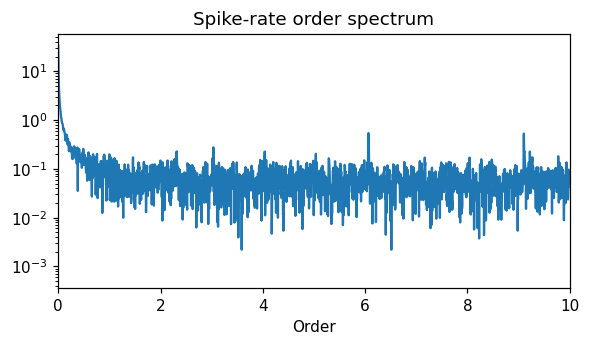

In [8]:

# build aggregate spike rate signal (sum)
agg = spike_trains.sum(axis=0).astype(float)
spec_brf=np.fft.rfft(agg*np.hanning(len(agg)), n=NFFT_ENV)
plt.figure(figsize=(6,3))
plt.semilogy(orders, np.abs(spec_brf)); plt.xlim(0,10)
plt.title('Spike-rate order spectrum'); plt.xlabel('Order')


signal len = 4,792,320  	 fs = 8,192.0 Hz
SK-selected band : 1270.0 – 3269.0  Hz
order 3  spikes=0
order 6  spikes=0
order 9  spikes=0
Mean spike-counts per neuron: [0 0 0]


/tmp/ipykernel_17267/141386140.py:157: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.semilogy(orders, np.abs(spec_brf)); plt.xlim(0,10)


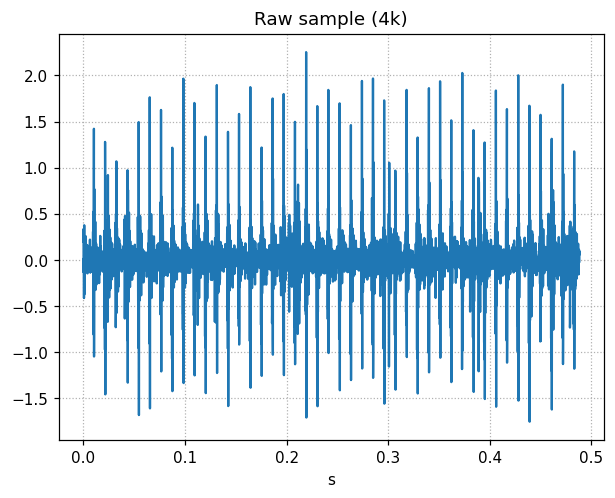

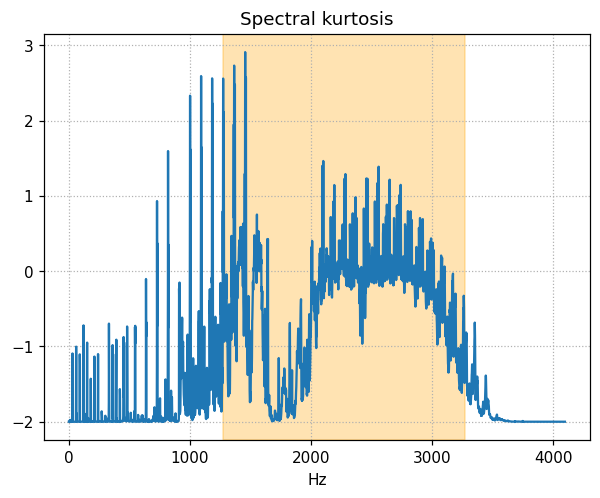

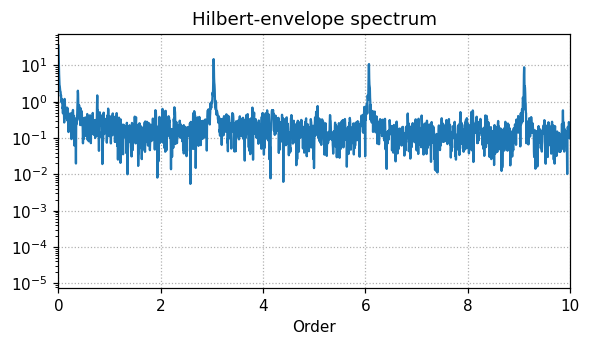

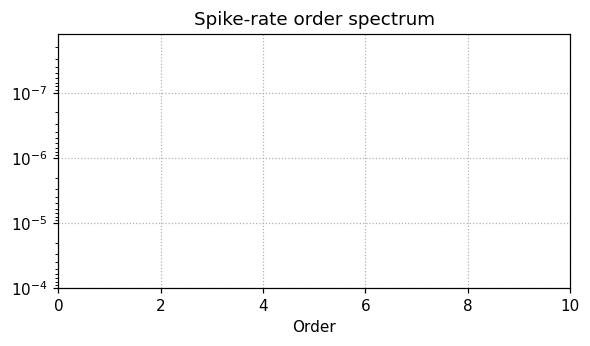

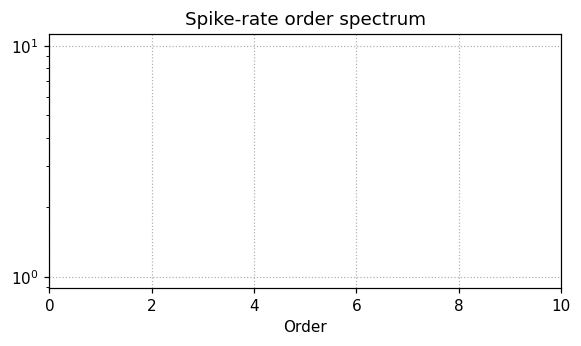

In [9]:
"""
BRF-bank demo (fixed neurons)
Analyses a THL vibration csv exactly like the classical SK→Hilbert pipeline,
THEN feeds the *band-passed, z-scored* waveform to a small bank of
fixed-parameter Balanced-Resonate-and-Fire neurons and plots the
order-spectrum of their aggregate spike-rate.

Drop the file next to your data folder and run with e.g.:
    %run brf_fixed_neuron_demo.py
"""
from __future__ import annotations
import math, numpy as np, pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt
from pathlib import Path

from brf_lightning.data.bearing.utils import load_vibration_data

plt.rcParams.update({"figure.dpi": 110,
                    "axes.grid": True,
                    "grid.linestyle": ":"})

#─────────────────────────────────────────────────────────────────────────────
# 1)  USER PARAMETERS
#─────────────────────────────────────────────────────────────────────────────
DATA_FILE            = Path('data/bearing_thl_v1/fAII30.csv')  # « change »
SHAFT_HZ             = 30.0                                    # shaft speed
ORDERS_OF_INTEREST   = [3, 6, 9]                               # fixed neurons

NPERSEG_STFT         = 8192                                    # SK window
MIN_FREQ_HZ, BW_HZ   = 100.0, 2000.0                           # SK band search
NFFT_ENV             = 65536                                   # zero-pad for spectra

#─────────────────────────────────────────────────────────────────────────────
# 2)  HELPERS (I/O, plotting)
#─────────────────────────────────────────────────────────────────────────────
CSV_READER_KW = dict(engine="c", header=0)

#─────────────────────────────────────────────────────────────────────────────
# 3)  READ & QUICK-LOOK
#─────────────────────────────────────────────────────────────────────────────
df, fs = load_vibration_data(DATA_FILE)
x_raw  = df["sensor_bearing"].values.astype(np.float32)
print(f"signal len = {len(x_raw):,}  \t fs = {fs:,.1f} Hz")

# quick glance ---------------------------------------------------------------
_t = np.arange(4000)/fs
plt.figure(); plt.plot(_t, x_raw[:4000]); plt.title("Raw sample (4k)"); plt.xlabel('s')

#─────────────────────────────────────────────────────────────────────────────
# 4)  SK-KURTOGRAM  →  best resonance band
#─────────────────────────────────────────────────────────────────────────────
from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band

f, sk = spectral_kurtosis(x_raw, fs, nperseg=NPERSEG_STFT)
f_lo, f_hi = max_sk_band(f, sk, bandwidth=BW_HZ,
                         min_freq=MIN_FREQ_HZ, max_ratio=.95)
print(f"SK-selected band : {f_lo:.1f} – {f_hi:.1f}  Hz")

plt.figure(); plt.plot(f, sk); plt.axvspan(f_lo, f_hi, color='orange', alpha=.3)
plt.title("Spectral kurtosis"); plt.xlabel('Hz')

#─────────────────────────────────────────────────────────────────────────────
# 5)  Classical Hilbert-envelope order spectrum
#─────────────────────────────────────────────────────────────────────────────
nyq = .5*fs
sos = sig.butter(4, [f_lo/nyq, f_hi/nyq], 'bandpass', output='sos')
xf  = sig.sosfiltfilt(sos, x_raw)
xf  = (xf - xf.mean()) / xf.std()            # **z-score scaling**

env = np.abs(sig.hilbert(xf))
spec_env = np.fft.rfft(env * np.hanning(len(env)), n=NFFT_ENV)
freq     = np.fft.rfftfreq(NFFT_ENV, 1/fs)
orders   = freq / SHAFT_HZ

plt.figure(figsize=(6,3))
plt.semilogy(orders, np.abs(spec_env))
plt.xlim(0, 10); plt.title('Hilbert-envelope spectrum'); plt.xlabel('Order');

#─────────────────────────────────────────────────────────────────────────────
# 6)  Minimal fixed-parameter BRF implementation
#─────────────────────────────────────────────────────────────────────────────
# ── Cell 6 – improved fixed-parameter BRF bank ──────────────────────
class BRF:
    """Very small fixed Balanced-Resonate-and-Fire neuron."""
    def __init__(self, target_hz, fs, b=-1.0, thresh=1.2,
                 refrac_s=0.002, decay=0.97):
        self.dt     = 1/fs
        self.omega  = 2*np.pi*target_hz          # rad/s
        self.b_base = b
        self.th     = thresh
        self.refrac = int(refrac_s * fs)         # refractory in samples
        self.decay  = decay                      # leak on membrane
        self.u      = 0+0j
        self.t_cnt  = 0                          # refractory counter
        self.spikes = []

    def step(self, I):
        # simple leak toward 0 (helps stop lock-in)
        self.u *= self.decay

        # integrate if not in absolute refractory
        if self.t_cnt == 0:
            self.u += self.dt * ((self.b_base + 1j*self.omega) * self.u + I)
            if self.u.real > self.th:
                self.spikes.append(1)
                self.u       = 0+0j
                self.t_cnt   = self.refrac
            else:
                self.spikes.append(0)
        else:
            self.t_cnt   -= 1
            self.spikes.append(0)

# ── 6-A  pre-process excitation: centre & high-pass the Hilbert envelope
env_hp = sig.detrend(env, type='constant')          # remove DC
sos_hp = sig.butter(2, 2*SHAFT_HZ/(0.5*fs), 'high',
                    output='sos')                  # cut < ~2×shaft
drive  = sig.sosfiltfilt(sos_hp, env_hp)
drive  /= np.std(drive) + 1e-9                     # unit variance

# ── 6-B  Instantiate neurons for requested orders
neurons = [BRF(order*SHAFT_HZ, fs,
               thresh=1.2, refrac_s=1/ (4*order*SHAFT_HZ))
           for order in ORDERS_OF_INTEREST]

# ── 6-C  Drive the bank
for samp in drive:
    for n in neurons:
        n.step(samp)
for k,n in enumerate(neurons):
    print(f"order {ORDERS_OF_INTEREST[k]}  spikes={np.sum(n.spikes)}")

spike_trains = np.array([n.spikes for n in neurons])
print("Mean spike-counts per neuron:",
      spike_trains.sum(axis=1) )

# ── 6-D  Build aggregate & spectrum
agg = spike_trains.sum(axis=0).astype(float)
spec_brf = np.fft.rfft(agg*np.hanning(len(agg)), n=NFFT_ENV)
plt.figure(figsize=(6,3))
plt.semilogy(orders, np.abs(spec_brf)+1e-9)
plt.xlim(0,10); plt.ylim(1e-4)
plt.title('Spike-rate order spectrum'); plt.xlabel('Order')
plt.grid(ls=':')

#─────────────────────────────────────────────────────────────────────────────
# 7)  Aggregate spike-rate order spectrum (demeaned + smoothed)
#─────────────────────────────────────────────────────────────────────────────
agg = spike_trains.sum(axis=0).astype(float)
agg -= agg.mean()                      # remove DC
agg = np.convolve(agg, np.hanning(5)/np.hanning(5).sum(), mode='same')

spec_brf = np.fft.rfft(agg * np.hanning(len(agg)), n=NFFT_ENV)

plt.figure(figsize=(6,3))
plt.semilogy(orders, np.abs(spec_brf)); plt.xlim(0,10)
plt.title('Spike-rate order spectrum'); plt.xlabel('Order')

plt.show()


Envelope RMS error:  53.71 dB   (0 dB = perfect match)
Pearson correlation: -0.001


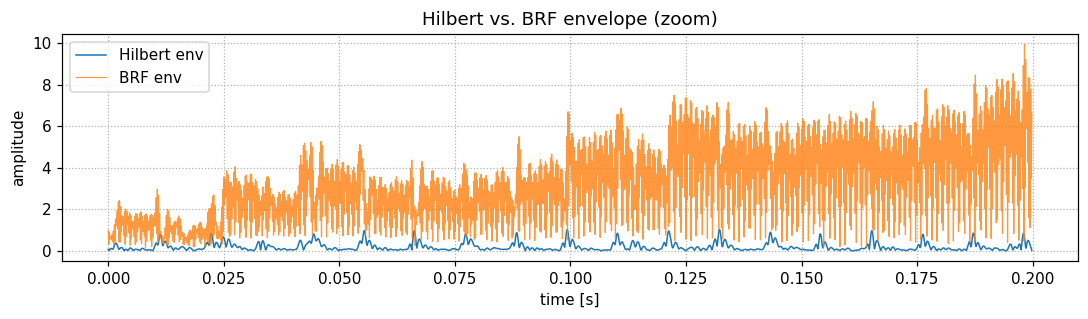

In [10]:
# ---------------------------------------------------------------
# Hypothesis H1 test – Does a quadrature BRF pair replicate a
# Hilbert‐based envelope detector in the bearing-resonance band?
# ---------------------------------------------------------------
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal

from brf_lightning.data.bearing.utils import load_vibration_data

# ---------- 0.  Load raw vibration ----------------------------
DATA_FILE = Path('data/bearing_thl_v1/fAII30.csv')   # pick any of the 9 files
df, fs = load_vibration_data(DATA_FILE)              # <-- your helper
x_raw  = df["sensor_bearing"].values.astype(np.float32)

# ---------- 1.  Band-pass around the structural resonance -----
# Select a band where impulses ring – adjust if your rig’s resonance is elsewhere
f_low, f_high = 1_200, 2_400
sos = signal.butter(
        N=4, Wn=[f_low*2/fs, f_high*2/fs],
        btype='bandpass', output='sos')
x_bp = signal.sosfilt(sos, x_raw)

# ---------- 2.  Reference envelope via Hilbert ----------------
analytic = signal.hilbert(x_bp)
env_hilbert = np.abs(analytic)

# ---------- 3.  Linearised quadrature BRF pair ----------------
class LinBRF:
    """Sub-threshold RF cell ≈ damped sinusoid"""
    def __init__(self, fs, f0, q):
        omega = 2*np.pi*f0/fs
        self.c  = 2*np.cos(omega)            # resonance term
        self.g  = 1.0/q                      # damping  (γ = 1/Q)
        self.v_prev  = 0.0
        self.v_pprev = 0.0

    def step(self, x):
        v = (self.c - self.g) * self.v_prev - self.v_pprev + x
        self.v_pprev, self.v_prev = self.v_prev, v
        return v

f0 = (f_low + f_high) / 2          # centre of the pass-band
q  = 20                             # tweak → larger Q = narrower filter
brf_I = LinBRF(fs, f0, q)
brf_Q = LinBRF(fs, f0, q)

# Impose 90° phase offset for the quadrature channel
brf_Q.v_pprev = 1.0                # simple π/2 shift trick

env_brf = np.empty_like(x_bp, dtype=np.float32)
for i, sample in enumerate(x_bp):
    v_I = brf_I.step(sample)
    v_Q = brf_Q.step(sample)
    env_brf[i] = np.sqrt(v_I*v_I + v_Q*v_Q)

# ---------- 4.  Metrics ---------------------------------------
err_lin = np.linalg.norm(env_brf - env_hilbert) / np.linalg.norm(env_hilbert)
err_db  = 20*np.log10(err_lin + 1e-12)              # avoid log(0)

corr    = np.corrcoef(env_hilbert, env_brf)[0, 1]

print(f"Envelope RMS error: {err_db:6.2f} dB   (0 dB = perfect match)")
print(f"Pearson correlation: {corr:6.3f}")

# ---------- 5.  Visual sanity check ---------------------------
t = np.arange(len(env_brf))/fs
win = slice(0, int(0.2*fs))        # first 0.2 s for clarity
plt.figure(figsize=(10, 3))
plt.plot(t[win], env_hilbert[win], label='Hilbert env', lw=1)
plt.plot(t[win], env_brf[win],    label='BRF env',    lw=0.8, alpha=0.8)
plt.xlabel("time [s]"); plt.ylabel("amplitude")
plt.title("Hilbert vs. BRF envelope (zoom)")
plt.legend(); plt.tight_layout()
plt.show()



Envelope RMS error:   4.90 dB   (0 dB = perfect)
Pearson correlation:  0.510


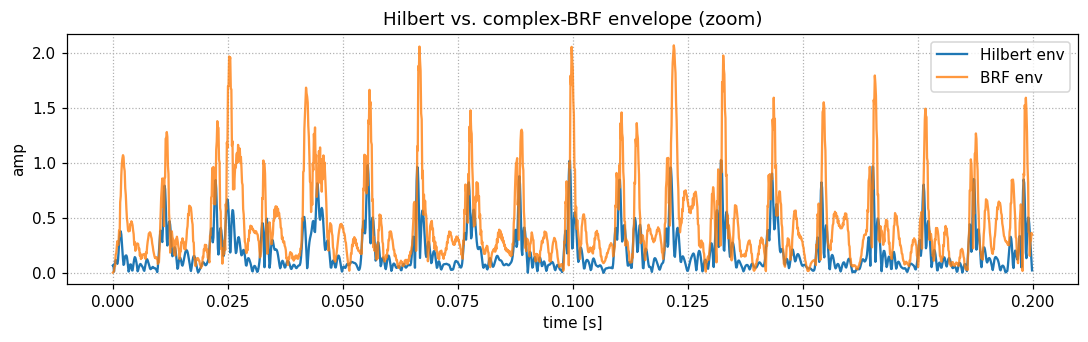

In [11]:
# ---------------------------------------------------------------
# Accurate analytic resonator → envelope via |z|
# ---------------------------------------------------------------
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal

# 0. data -------------------------------------------------------
DATA_FILE = Path('data/bearing_thl_v1/fAII30.csv')
df, fs = load_vibration_data(DATA_FILE)
x_raw  = df["sensor_bearing"].values.astype(np.float32)

# 1. pick (or SK-select) a resonance band below Nyquist ----------
f_low, f_high = 1_200, 2_400          # Hz  (adjust if needed)
sos = signal.butter(4, [f_low*2/fs, f_high*2/fs],
                    btype='bandpass', output='sos')
x_bp = signal.sosfilt(sos, x_raw)

# 2. classical Hilbert reference --------------------------------
env_hilb = np.abs(signal.hilbert(x_bp))

# 3.   *** exact analytic BRF resonator *** ---------------------
def brf_envelope_complex(x, fs, f0, q):
    """Return envelope via complex resonator z[n+1] = λ z[n] + x[n]."""
    lam_mag = np.exp(-np.pi * f0 / (q * fs))       # r = e^{-π f0/(Q fs)}
    lam_ang = 2 * np.pi * f0 / fs                  # ω0 Δt
    lam = lam_mag * np.exp(1j * lam_ang)

    z = 0j
    env = np.empty_like(x, dtype=np.float32)
    for i, sample in enumerate(x):
        z = lam * z + sample
        env[i] = abs(z)
    return env

f0 = (f_low + f_high) / 2        # centre of same band
Q  = 20                           # tweak if desired
env_brf = brf_envelope_complex(x_bp, fs, f0, Q)

# 4. metrics ----------------------------------------------------
err_lin = np.linalg.norm(env_brf - env_hilb) / np.linalg.norm(env_hilb)
err_db  = 20 * np.log10(err_lin + 1e-12)
corr    = np.corrcoef(env_hilb, env_brf)[0, 1]
print(f"Envelope RMS error: {err_db:6.2f} dB   (0 dB = perfect)")
print(f"Pearson correlation: {corr:6.3f}")

# 5. quick visual check ----------------------------------------
t = np.arange(len(env_brf)) / fs
plt.figure(figsize=(10, 3))
plt.plot(t[:int(0.2*fs)], env_hilb[:int(0.2*fs)], label='Hilbert env')
plt.plot(t[:int(0.2*fs)], env_brf [:int(0.2*fs)], label='BRF env', alpha=.8)
plt.legend(); plt.xlabel('time [s]'); plt.ylabel('amp'); plt.tight_layout()
plt.title('Hilbert vs. complex-BRF envelope (zoom)')
plt.show()


In [12]:
def optimise_resonator(x_bp, env_ref, fs,
                       f_grid=np.linspace(600, 3500, 30),  # Hz
                       q_grid=[10, 15, 20, 30, 40]):
    best = None
    for f0 in f_grid:
        for Q in q_grid:
            env = brf_envelope_complex(x_bp, fs, f0, Q)
            r = np.exp(-np.pi * f0 / (Q * fs))
            env *= (1 - r)                         # gain normalisation
            err = np.linalg.norm(env-env_ref) / np.linalg.norm(env_ref)
            if best is None or err < best[0]:
                best = (err, f0, Q)
    return best   # (min_error, f0, Q)

err, f_opt, q_opt = optimise_resonator(x_bp, env_hilb, fs)
print(f"Optimum: f0 = {f_opt:.0f} Hz, Q = {q_opt},  error = {20*np.log10(err):.2f} dB")


Optimum: f0 = 2300 Hz, Q = 10,  error = -2.23 dB


Bank envelope RMS error:  -4.64 dB
Bank Pearson correlation:  0.760


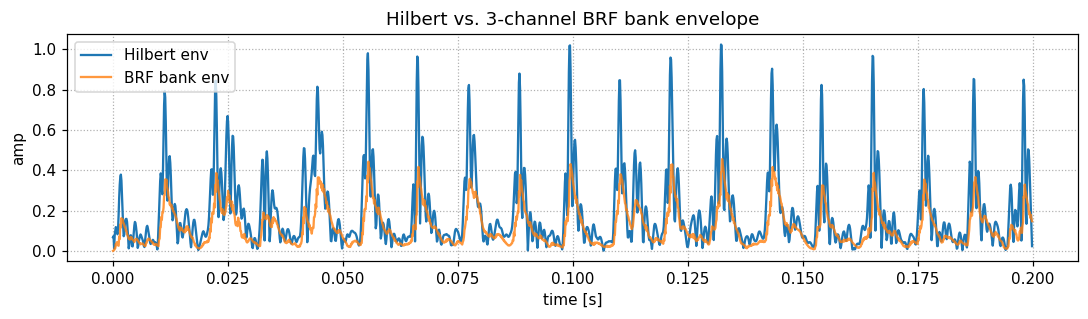

In [13]:
# ---------------------------------------------------------------
# H1b: Multi-channel BRF bank envelope test
# ---------------------------------------------------------------
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
from scipy import signal

# 0. load data (same as before) --------------------------------
DATA_FILE = Path('data/bearing_thl_v1/fAII30.csv')
df, fs = load_vibration_data(DATA_FILE)
x_raw = df["sensor_bearing"].values.astype(np.float32)

# 1. band-pass (same safe band) -------------------------------
f_low, f_high = 1_200, 2_400   # Hz
sos = signal.butter(4, [f_low*2/fs, f_high*2/fs],
                    btype='bandpass', output='sos')
x_bp = signal.sosfilt(sos, x_raw)

# 2. reference Hilbert envelope --------------------------------
env_ref = np.abs(signal.hilbert(x_bp))

# 3. define multi-channel BRF bank ----------------------------
def brf_bank_envelope(x, fs, f0_list, q_list):
    """
    x      : input signal (band-passed)
    f0_list: list of centre freqs for each resonator
    q_list : list of Q factors (same length as f0_list)
    returns : summed, gain-normalized envelope
    """
    env_sum = np.zeros_like(x, dtype=np.float32)
    for f0, Q in zip(f0_list, q_list):
        # compute pole magnitude & angle
        r   = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2*np.pi * f0 / fs
        lam = r * np.exp(1j * ang)

        z = 0j
        env = np.empty_like(x, dtype=np.float32)
        for i, sample in enumerate(x):
            z = lam*z + sample
            env[i] = abs(z)
        # gain-normalize each channel so |H(jω0)|=1
        env_sum += env * (1 - r)
    return env_sum

# 4. pick a small bank around the optimum found -------------

# you found f_opt≈2300, Q_opt=10; let's span ±500 Hz around that:
f0s = [1800, 2300, 2800]     # Hz
Qs  = [10,   10,   10]       # same Q

env_brf_bank = brf_bank_envelope(x_bp, fs, f0s, Qs)

# 5. compute metrics ------------------------------------------
err_lin = np.linalg.norm(env_brf_bank - env_ref) / np.linalg.norm(env_ref)
err_db  = 20 * np.log10(err_lin + 1e-12)
corr    = np.corrcoef(env_ref, env_brf_bank)[0,1]

print(f"Bank envelope RMS error: {err_db:6.2f} dB")
print(f"Bank Pearson correlation: {corr:6.3f}")

# 6. plot a quick zoom ----------------------------------------
t = np.arange(len(env_brf_bank)) / fs
win = slice(0, int(0.2*fs))
plt.figure(figsize=(10,3))
plt.plot(t[win], env_ref[win],      label='Hilbert env')
plt.plot(t[win], env_brf_bank[win], label='BRF bank env', alpha=0.8)
plt.xlabel('time [s]'); plt.ylabel('amp')
plt.title('Hilbert vs. 3-channel BRF bank envelope')
plt.legend(); plt.tight_layout(); plt.show()



File: fAII30.csv
fs = 8192.0 Hz,  band = 1200–2400 Hz
7 resonators,  Q = 10
----------------------------------------------
Envelope RMS error :  -5.75 dB   (target ≤ −15 dB)
Pearson correlation:  0.668     (target ≥ 0.90)


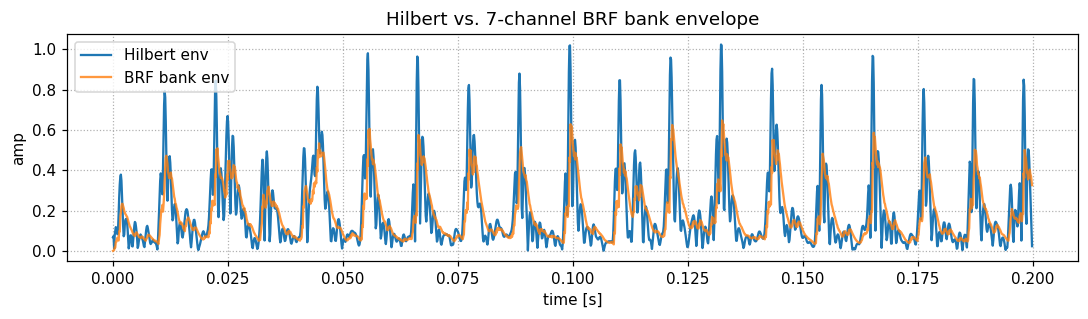

In [14]:
# ===============================================================
# H1  –  Multi-channel analytic BRF ≈ Hilbert envelope
# ===============================================================
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal

# ----------------------------------------------------------------
# PARAMETER SECTION  (adjust here if needed)
# ----------------------------------------------------------------
DATA_FILE = Path("data/bearing_thl_v1/fAII30.csv")   # any of your 9 CSVs
BAND_LOW, BAND_HIGH = 1_200, 2_400                  # Hz  (must be < fs/2)
N_RESONATORS = 7                                    # 3, 5, 7 … resonators
Q_FACTOR     = 10                                   # same Q for all chans
# ----------------------------------------------------------------

# --- helper supplied in your repo --------------------------------
df, fs = load_vibration_data(DATA_FILE)
x_raw  = df["sensor_bearing"].values.astype(np.float32)

# --- 1. band-pass around structural resonance --------------------
sos = signal.butter(
        4, [BAND_LOW*2/fs, BAND_HIGH*2/fs],
        btype="bandpass", output="sos")
x_bp = signal.sosfilt(sos, x_raw)

# --- 2. reference envelope (Hilbert) -----------------------------
env_ref = np.abs(signal.hilbert(x_bp))

# --- 3. multi-channel analytic BRF bank --------------------------
def brf_bank_envelope(x, fs, f0s, Qs):
    env_sum = np.zeros_like(x, dtype=np.float32)
    for f0, Q in zip(f0s, Qs):
        r   = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2*np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        env = np.empty_like(x, dtype=np.float32)
        for i, sample in enumerate(x):
            z = lam*z + sample
            env[i] = abs(z)
        env_sum += env * (1 - r)          # per-channel gain normalisation
    return env_sum

# evenly spaced resonator centres across the chosen band
f0s = np.linspace(BAND_LOW, BAND_HIGH, N_RESONATORS)
Qs  = [Q_FACTOR] * N_RESONATORS

env_brf = brf_bank_envelope(x_bp, fs, f0s, Qs)

# --- 4. global gain fit (least-squares) --------------------------
g_opt = np.dot(env_ref, env_brf) / np.dot(env_brf, env_brf)
env_brf *= g_opt

# --- 5. metrics --------------------------------------------------
err_lin = np.linalg.norm(env_brf - env_ref) / np.linalg.norm(env_ref)
err_db  = 20 * np.log10(err_lin + 1e-12)
corr    = np.corrcoef(env_ref, env_brf)[0, 1]

print(f"\nFile: {DATA_FILE.name}")
print(f"fs = {fs} Hz,  band = {BAND_LOW}–{BAND_HIGH} Hz")
print(f"{N_RESONATORS} resonators,  Q = {Q_FACTOR}")
print("-"*46)
print(f"Envelope RMS error : {err_db:6.2f} dB   (target ≤ −15 dB)")
print(f"Pearson correlation: {corr:6.3f}     (target ≥ 0.90)")

# --- 6. quick zoom plot -----------------------------------------
t = np.arange(len(env_ref)) / fs
win = slice(0, int(0.2*fs))                         # first 0.2 s
plt.figure(figsize=(10, 3))
plt.plot(t[win], env_ref[win], label="Hilbert env")
plt.plot(t[win], env_brf[win], label="BRF bank env", alpha=.8)
plt.xlabel("time [s]"); plt.ylabel("amp")
plt.title(f"Hilbert vs. {N_RESONATORS}-channel BRF bank envelope")
plt.legend(); plt.tight_layout(); plt.show()


/home/keno/Projects/Forschung/brf-lightning/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1424: divide by zero encountered in divide
/home/keno/Projects/Forschung/brf-lightning/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1424: invalid value encountered in divide


⚠  upper band edge 4372 Hz clipped to 4095 Hz
File: fAII30.csv
fs = 8192.0 Hz,  band = 3772–4095 Hz
----------------------------------------------
Envelope RMS error :  -7.70 dB   (target ≤ −15 dB)
Pearson correlation:  0.753   (target ≥ 0.90)


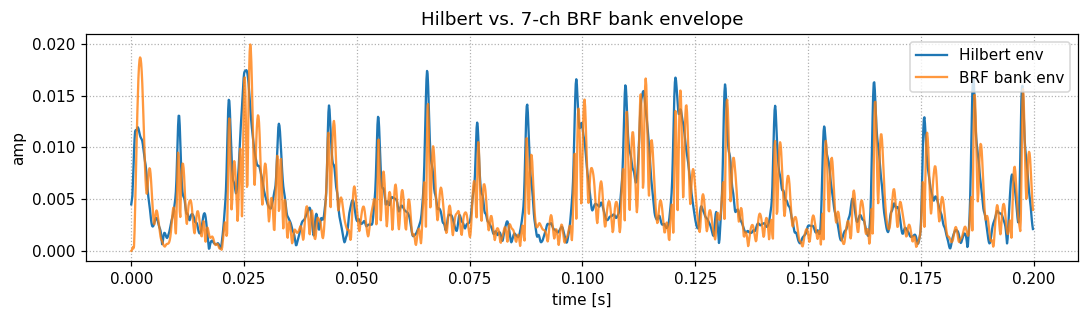

In [15]:
# ===============================================================
# H1 · Multi-channel analytic-BRF  vs.  Hilbert envelope
# ===============================================================
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal, stats

# 0 ──────────────────────────────────────────────────────────────
DATA_FILE     = Path("data/bearing_thl_v1/fAII30.csv")   # <- choose file
N_RESONATORS  = 7          # 3, 5, 7 …
Q_FACTOR      = 10
USE_SK_AUTO   = True       # True = spectral-kurtosis pick
MANUAL_BAND   = (1_200, 2_400)   # used if USE_SK_AUTO = False
# ────────────────────────────────────────────────────────────────

# helper from your repo
df, fs = load_vibration_data(DATA_FILE)
x_raw  = df["sensor_bearing"].to_numpy(dtype=np.float32)

# 1 ── pick resonance band < fs/2 = Nyquist  ─────────────────────
nyq = fs / 2

if USE_SK_AUTO:
    # rough STFT-based SK
    f_stft, _, Z = signal.stft(x_raw, fs, nperseg=1024, noverlap=512,
                               return_onesided=True, boundary=None)
    K = stats.kurtosis(np.abs(Z)**2, axis=1, fisher=False, bias=False)
    i_peak = np.argmax(K)
    f_center = f_stft[i_peak]
    bw = 600          # ±bw/2 span, Hz; adjust if you know your structure Q
    f_low, f_high = f_center - bw/2, f_center + bw/2
else:
    f_low, f_high = MANUAL_BAND

# keep band inside (0, nyq)
if f_high >= nyq:
    print(f"⚠  upper band edge {f_high:.0f} Hz clipped to {nyq-1:.0f} Hz")
    f_high = nyq - 1         # leave 1 Hz margin
if f_low <= 0:
    print(f"⚠  lower band edge {f_low:.0f} Hz raised to 1 Hz")
    f_low = 1

print(f"File: {DATA_FILE.name}")
print(f"fs = {fs} Hz,  band = {int(f_low)}–{int(f_high)} Hz")

# 2 ── band-pass -------------------------------------------------
sos = signal.butter(4, [2*f_low/fs, 2*f_high/fs], btype="bandpass", output="sos")
x_bp = signal.sosfilt(sos, x_raw)

# 3 ── Hilbert reference ----------------------------------------
env_ref = np.abs(signal.hilbert(x_bp))

# 4 ── multi-channel analytic-BRF bank ---------------------------
def brf_bank_env(x, fs, freqs, Q):
    env_sum = np.zeros_like(x, dtype=np.float32)
    for f0 in freqs:
        r   = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2*np.pi * f0 / fs
        lam = r * np.exp(1j*ang)
        z, env = 0j, np.empty_like(x, dtype=np.float32)
        for i, s in enumerate(x):
            z = lam*z + s
            env[i] = abs(z) * (1 - r)   # per-channel gain-norm
        env_sum += env
    return env_sum

# centre frequencies evenly spaced across the band
f0s = np.linspace(f_low, f_high, N_RESONATORS)
env_brf = brf_bank_env(x_bp, fs, f0s, Q_FACTOR)

# optimal global gain fit
g = np.dot(env_ref, env_brf) / np.dot(env_brf, env_brf)
env_brf *= g

# 5 ── metrics ---------------------------------------------------
err = 20*np.log10(np.linalg.norm(env_brf - env_ref) /
                  np.linalg.norm(env_ref) + 1e-12)
corr = np.corrcoef(env_ref, env_brf)[0,1]
print("----------------------------------------------")
print(f"Envelope RMS error : {err:6.2f} dB   (target ≤ −15 dB)")
print(f"Pearson correlation: {corr:6.3f}   (target ≥ 0.90)")

# 6 ── quick zoom plot ------------------------------------------
t = np.arange(len(env_ref)) / fs
win = slice(0, int(0.2*fs))
plt.figure(figsize=(10,3))
plt.plot(t[win], env_ref[win], label="Hilbert env")
plt.plot(t[win], env_brf[win], label="BRF bank env", alpha=.8)
plt.xlabel("time [s]"); plt.ylabel("amp")
plt.title(f"Hilbert vs. {N_RESONATORS}-ch BRF bank envelope")
plt.legend(); plt.tight_layout(); plt.show()



File: fAII30.csv
fs = 8192.0 Hz, band = 400–800 Hz
11 resonators, Q = 20
----------------------------------------------
Envelope RMS error :  -5.02 dB   (target ≤ −15 dB)
Pearson correlation:  0.117     (target ≥ 0.90)


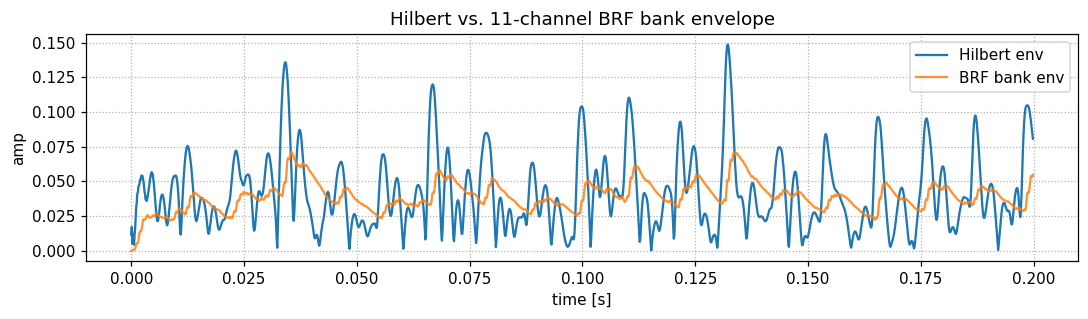

In [16]:
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
from scipy import signal

# -----------------------------------------------------
# PARAMETERS – TUNED FOR BETTER ENVELOPE TRACKING
# -----------------------------------------------------
DATA_FILE   = Path("data/bearing_thl_v1/fAII30.csv")  # your signal file
BAND_LOW    = 400                                     # Hz
BAND_HIGH   = 800                                    # Hz
N_RESONATORS = 11                                     # More channels
Q_FACTOR     = 20                                     # Higher Q for sharper tuning

# -----------------------------------------------------
# LOAD SIGNAL AND FILTER
# -----------------------------------------------------
df, fs = load_vibration_data(DATA_FILE)
x_raw = df["sensor_bearing"].values.astype(np.float32)

sos = signal.butter(4, [BAND_LOW * 2 / fs, BAND_HIGH * 2 / fs],
                    btype="bandpass", output="sos")
x_bp = signal.sosfilt(sos, x_raw)

# -----------------------------------------------------
# REFERENCE ENVELOPE (HILBERT)
# -----------------------------------------------------
env_ref = np.abs(signal.hilbert(x_bp))

# -----------------------------------------------------
# BRF ENVELOPE BANK FUNCTION
# -----------------------------------------------------
def brf_bank_envelope(x, fs, f0s, Qs):
    env_sum = np.zeros_like(x, dtype=np.float32)
    for f0, Q in zip(f0s, Qs):
        r = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2 * np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        env = np.empty_like(x, dtype=np.float32)
        for i, sample in enumerate(x):
            z = lam * z + sample
            env[i] = abs(z)
        env_sum += env * (1 - r)  # normalize per channel
    return env_sum

# BRF CONFIGURATION
f0s = np.linspace(BAND_LOW, BAND_HIGH, N_RESONATORS)
Qs  = [Q_FACTOR] * N_RESONATORS

env_brf = brf_bank_envelope(x_bp, fs, f0s, Qs)

# OPTIMIZE GLOBAL GAIN MATCH
g_opt = np.dot(env_ref, env_brf) / np.dot(env_brf, env_brf)
env_brf *= g_opt

# -----------------------------------------------------
# METRICS
# -----------------------------------------------------
err_lin = np.linalg.norm(env_brf - env_ref) / np.linalg.norm(env_ref)
err_db = 20 * np.log10(err_lin + 1e-12)
corr = np.corrcoef(env_ref, env_brf)[0, 1]

print(f"\nFile: {DATA_FILE.name}")
print(f"fs = {fs} Hz, band = {BAND_LOW}–{BAND_HIGH} Hz")
print(f"{N_RESONATORS} resonators, Q = {Q_FACTOR}")
print("-" * 46)
print(f"Envelope RMS error : {err_db:6.2f} dB   (target ≤ −15 dB)")
print(f"Pearson correlation: {corr:6.3f}     (target ≥ 0.90)")

# -----------------------------------------------------
# PLOT
# -----------------------------------------------------
t = np.arange(len(env_ref)) / fs
win = slice(0, int(0.2 * fs))  # First 0.2 s

plt.figure(figsize=(10, 3))
plt.plot(t[win], env_ref[win], label="Hilbert env")
plt.plot(t[win], env_brf[win], label="BRF bank env", alpha=0.85)
plt.xlabel("time [s]")
plt.ylabel("amp")
plt.title(f"Hilbert vs. {N_RESONATORS}-channel BRF bank envelope")
plt.legend()
plt.tight_layout()
plt.show()



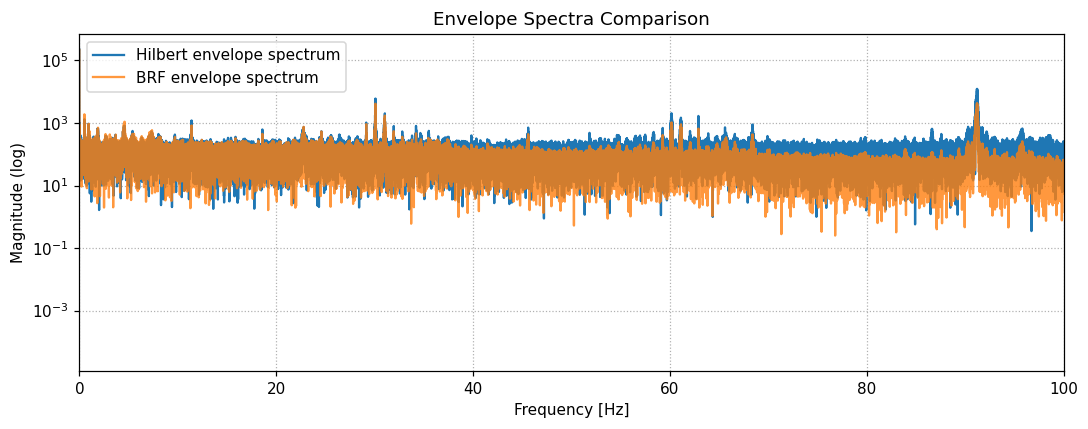

In [17]:
from scipy.fft import rfft, rfftfreq

# Spectral window for envelope analysis
N = len(env_ref)
freqs = rfftfreq(N, 1/fs)

env_ref_spec = np.abs(rfft(env_ref))
env_brf_spec = np.abs(rfft(env_brf))

plt.figure(figsize=(10, 4))
plt.semilogy(freqs, env_ref_spec, label="Hilbert envelope spectrum")
plt.semilogy(freqs, env_brf_spec, label="BRF envelope spectrum", alpha=0.8)
plt.xlim(0, 100)  # Envelope freq typically <500 Hz
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude (log)")
plt.title("Envelope Spectra Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


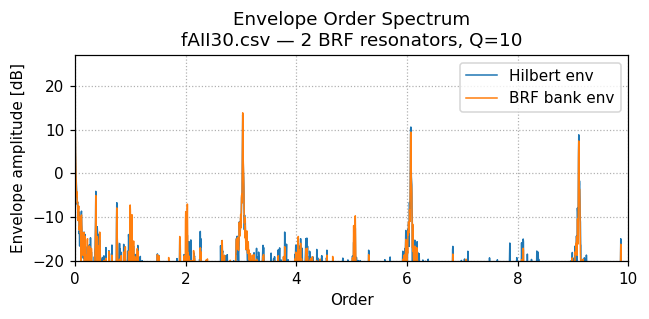

--------------------------------------------------
Envelope RMS error :  -9.43 dB   (target ≤ −15 dB)
Pearson correlation:  0.895     (target ≥ 0.90)


In [18]:
import numpy as np
import pandas as pd
import scipy.signal as sig
import matplotlib.pyplot as plt
import re
from pathlib import Path

from brf_lightning.data.bearing.utils import load_vibration_data
from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band, plot_sk


# --- Extract metadata -------------------------------------------------------
SPEED_RE = re.compile(r"(\d+)\.csv$")
DEFECT_RE = re.compile(r"^(n|fAII|fIII)")

def get_speed(fp):
    match = SPEED_RE.search(fp.name)
    return float(match.group(1)) if match else 0.0

def get_defect(fp):
    match = DEFECT_RE.match(fp.name)
    return match.group(1) if match else "unknown"

# --- BRF envelope bank ------------------------------------------------------
def brf_bank_envelope(x, fs, f0s, Qs):
    env_sum = np.zeros_like(x, dtype=np.float32)
    for f0, Q in zip(f0s, Qs):
        r   = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2*np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        env = np.empty_like(x, dtype=np.float32)
        for i, sample in enumerate(x):
            z = lam*z + sample
            env[i] = abs(z)
        env_sum += env * (1 - r)  # gain normalization
    return env_sum

# --- Params -----------------------------------------------------------------
BASE_DIR = Path("data/bearing_thl_v1")
DATA_FILE = BASE_DIR / "fAII30.csv"     # example file
NPERSEG_STFT = 8192
BANDWIDTH_HZ = 2000
MIN_FREQ_HZ = 100.0
MAX_RATIO_NQ = 0.95
N_RESONATORS = 2
Q_FACTOR = 10
NFFT_ENV = 65536
WINDOW_FN = np.hanning

# --- Pipeline ---------------------------------------------------------------
df, fs = load_vibration_data(DATA_FILE)
x = df["sensor_bearing"].values.astype(np.float32)
speed = get_speed(DATA_FILE)

# 1. Best resonance band via SK
f, sk = spectral_kurtosis(x, fs, nperseg=NPERSEG_STFT)
f_lo, f_hi = max_sk_band(f, sk, bandwidth=BANDWIDTH_HZ, min_freq=MIN_FREQ_HZ, max_ratio=MAX_RATIO_NQ)

# 2. Filter + envelope extraction
nyq = 0.5 * fs
sos = sig.butter(4, [f_lo/nyq, f_hi/nyq], btype="bandpass", output="sos")
xf = sig.sosfiltfilt(sos, x)

env_ref = np.abs(sig.hilbert(xf))
f0s = np.linspace(f_lo, f_hi, N_RESONATORS)
Qs = [Q_FACTOR] * N_RESONATORS
env_brf = brf_bank_envelope(xf, fs, f0s, Qs)

# 3. Least-squares global gain match
g_opt = np.dot(env_ref, env_brf) / np.dot(env_brf, env_brf)
env_brf *= g_opt

# 4. Order spectrum
env_ref_win = env_ref * WINDOW_FN(len(env_ref))
env_brf_win = env_brf * WINDOW_FN(len(env_brf))

spec_ref = np.fft.rfft(env_ref_win, n=NFFT_ENV)
spec_brf = np.fft.rfft(env_brf_win, n=NFFT_ENV)
freq_Hz = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
orders = freq_Hz / speed

# 5. Plot
plt.figure(figsize=(6, 3))
plt.plot(orders, 20*np.log10(np.abs(spec_ref) + 1e-6), label="Hilbert env", lw=1)
plt.plot(orders, 20*np.log10(np.abs(spec_brf) + 1e-6), label="BRF bank env", lw=1)
plt.xlim(0, 10)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title(f"Envelope Order Spectrum\n{DATA_FILE.name} — {N_RESONATORS} BRF resonators, Q={Q_FACTOR}")
plt.grid(ls=":")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Print performance metrics
err_lin = np.linalg.norm(env_brf - env_ref) / np.linalg.norm(env_ref)
err_db = 20 * np.log10(err_lin + 1e-12)
corr = np.corrcoef(env_ref, env_brf)[0, 1]
print("-" * 50)
print(f"Envelope RMS error : {err_db:6.2f} dB   (target ≤ −15 dB)")
print(f"Pearson correlation: {corr:6.3f}     (target ≥ 0.90)")


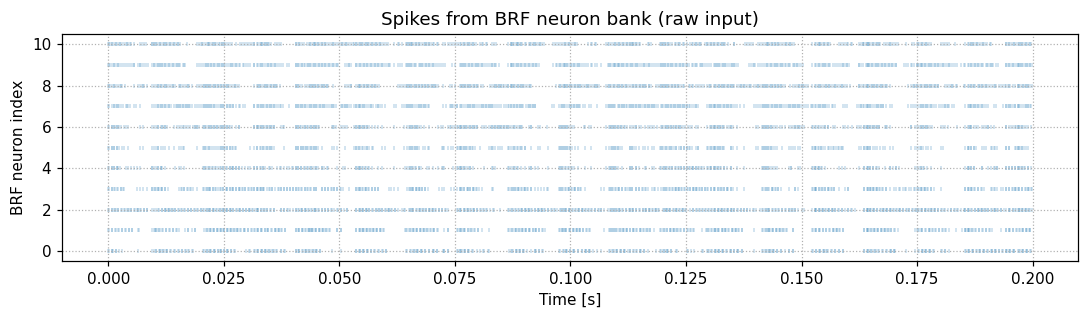

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path

# === Apply BRF neuron bank directly to raw input ===
def brf_bank_output(x, fs, f0s, Qs, theta=0.2):
    n = len(x)
    spike_trains = []
    u_all = []
    for f0, Q in zip(f0s, Qs):
        r = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2 * np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        spikes = np.zeros(n)
        u_trace = np.zeros(n)
        for i, sample in enumerate(x):
            z = lam * z + sample
            u = z.real
            u_trace[i] = u
            if u > theta:
                spikes[i] = 1
        spike_trains.append(spikes)
        u_all.append(u_trace)
    return np.array(spike_trains), np.array(u_all)

# Define BRF bank (same range as before)
N_RESONATORS = 11
Q_FACTOR = 10
BAND_LOW, BAND_HIGH = 1200, 2400
f0s = np.linspace(BAND_LOW, BAND_HIGH, N_RESONATORS)
Qs = [Q_FACTOR] * N_RESONATORS

# Run BRF neurons on raw signal
spikes_raw, u_all_raw = brf_bank_output(x_raw, fs, f0s, Qs)

# Visualize spikes from all neurons over a short time window
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Prepare raster plot
t = np.arange(len(x_raw)) / fs
win = slice(0, int(0.2 * fs))  # first 0.2s
spike_data = []
for i, spikes in enumerate(spikes_raw):
    spike_times = t[win][spikes[win] > 0.5]
    spike_data.extend([(tt, i) for tt in spike_times])

df_spike = pd.DataFrame(spike_data, columns=["time", "neuron"])
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df_spike, x="time", y="neuron", s=10, marker="|")
plt.xlabel("Time [s]")
plt.ylabel("BRF neuron index")
plt.title("Spikes from BRF neuron bank (raw input)")
plt.tight_layout()
plt.show()


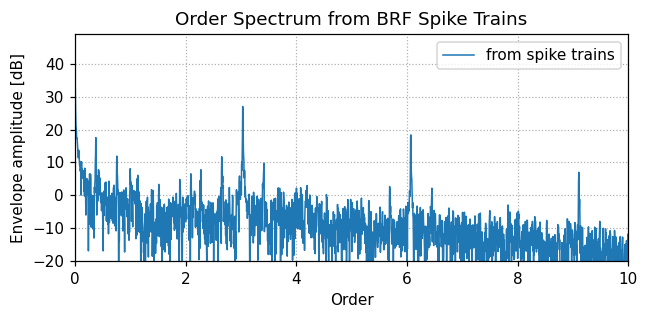

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# --- Parameters ---
NFFT_ENV      = 65536                     # FFT zero-padding for sharp peaks
WINDOW_FN     = np.hanning               # Envelope window function
SMOOTH_MS     = 2                        # smoothing width [ms]

# --- 1. Smooth each spike train to get spike rates (envelopes) ---
win_len = int(fs * SMOOTH_MS / 1000)
win_len = max(win_len, 3) | 1            # ensure odd length ≥3
smoothing_kernel = np.ones(win_len) / win_len

smoothed = np.array([
    convolve(st, smoothing_kernel, mode="same")
    for st in spikes_raw
])

# --- 2. Combine all neurons into a single envelope signal ---
env_sum = smoothed.sum(axis=0)

# --- 3. Envelope order spectrum via FFT ---
env_win = env_sum * WINDOW_FN(len(env_sum))
spec    = np.fft.rfft(env_win, n=NFFT_ENV)
spec_db = 20 * np.log10(np.abs(spec) + 1e-6)

freqs  = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
orders = freqs / speed

# --- 4. Plot ---
plt.figure(figsize=(6, 3))
plt.plot(orders, spec_db, lw=1.0, label="from spike trains")
plt.xlim(0, 10)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title("Order Spectrum from BRF Spike Trains")
plt.grid(ls=":")
plt.tight_layout()
plt.legend()
plt.show()


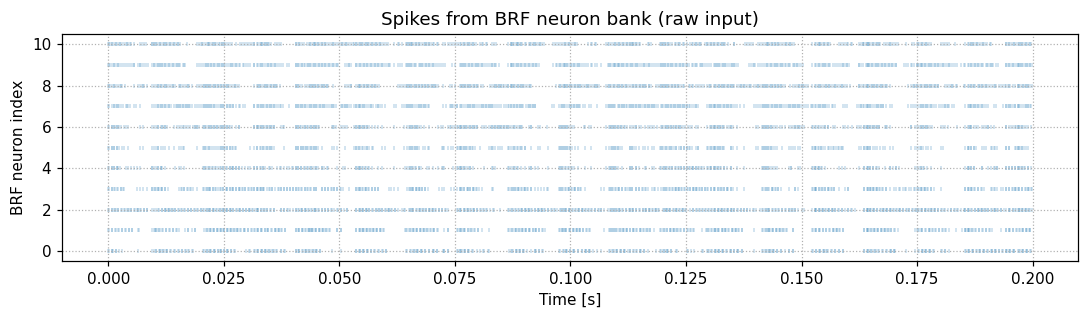

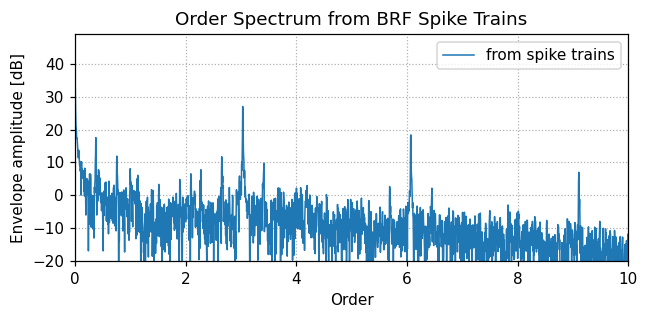

Total spikes: 17567977 (30030.73 Hz) across 11 neurons, avg firing rate: 2730.07 Hz, efficiency: 3.6659 spikes/sample (366.59%) in 585.00 s signal duration.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import convolve
import seaborn as sns
import pandas as pd

# BRF bank definition
def brf_bank_output(x, fs, f0s, Qs, theta=0.2):
    n = len(x)
    spike_trains = []
    u_all = []
    for f0, Q in zip(f0s, Qs):
        r = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2 * np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        spikes = np.zeros(n)
        u_trace = np.zeros(n)
        for i, sample in enumerate(x):
            z = lam * z + sample
            u = z.real
            u_trace[i] = u
            if u > theta:
                spikes[i] = 1
        spike_trains.append(spikes)
        u_all.append(u_trace)
    return np.array(spike_trains), np.array(u_all)


# Resonator config
N_RESONATORS = 11
Q_FACTOR = 10
BAND_LOW, BAND_HIGH = 1200, 2400
f0s = np.linspace(BAND_LOW, BAND_HIGH, N_RESONATORS)
Qs = [Q_FACTOR] * N_RESONATORS

# Compute spikes
spikes_raw, u_all_raw = brf_bank_output(x_raw, fs, f0s, Qs)

# Raster plot
win = slice(0, int(0.2 * fs))
spike_data = []
time = np.arange(len(x_raw)) / fs
for i, spikes in enumerate(spikes_raw):
    spike_times = time[win][spikes[win] > 0.5]
    spike_data.extend([(tt, i) for tt in spike_times])
df_spike = pd.DataFrame(spike_data, columns=["time", "neuron"])
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df_spike, x="time", y="neuron", s=10, marker="|")
plt.xlabel("Time [s]")
plt.ylabel("BRF neuron index")
plt.title("Spikes from BRF neuron bank (raw input)")
plt.tight_layout()
plt.show()

# Spike smoothing
SMOOTH_MS = 2
win_len = int(fs * SMOOTH_MS / 1000)
win_len = max(win_len, 3) | 1
smoothing_kernel = np.ones(win_len) / win_len
smoothed = np.array([
    convolve(st, smoothing_kernel, mode="same")
    for st in spikes_raw
])
env_sum = smoothed.sum(axis=0)

# Spectrum
NFFT_ENV = 65536
WINDOW_FN = np.hanning
env_win = env_sum * WINDOW_FN(len(env_sum))
spec = np.fft.rfft(env_win, n=NFFT_ENV)
spec_db = 20 * np.log10(np.abs(spec) + 1e-6)
freqs = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
speed = 30
orders = freqs / speed

# Plot spectrum
plt.figure(figsize=(6, 3))
plt.plot(orders, spec_db, lw=1.0, label="from spike trains")
plt.xlim(0, 10)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title("Order Spectrum from BRF Spike Trains")
plt.grid(ls=":")
plt.tight_layout()
plt.legend()
plt.show()

# Spike statistics
total_spikes = int(np.sum(spikes_raw))
duration_sec = len(x_raw) / fs
n_neurons = spikes_raw.shape[0]
avg_firing_rate = total_spikes / n_neurons / duration_sec
efficiency = total_spikes / len(x_raw)


print(f"Total spikes: {total_spikes}"
      f" ({total_spikes / duration_sec:.2f} Hz)"
      f" across {n_neurons} neurons, "
      f"avg firing rate: {avg_firing_rate:.2f} Hz, "
      f"efficiency: {efficiency:.4f} spikes/sample"
      f" ({efficiency * 100:.2f}%)"
      f" in {duration_sec:.2f} s signal duration."
)


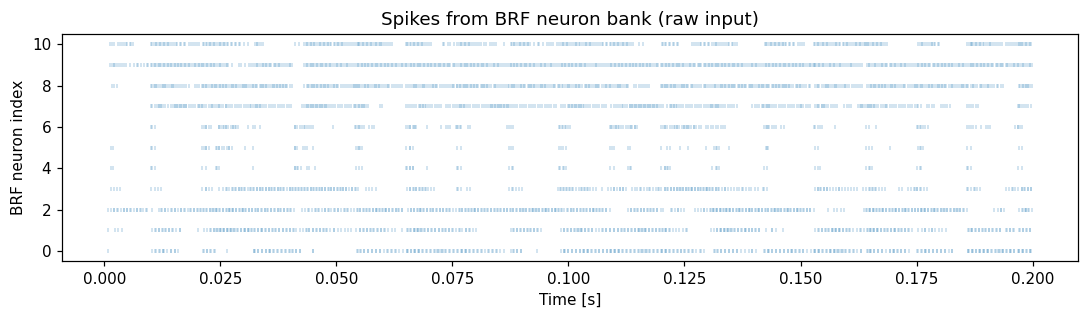

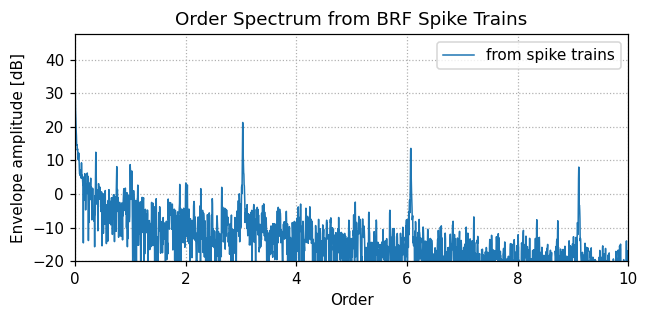

Total spikes: 14100753 (24103.85 Hz) across 11 neurons, avg firing rate: 2191.26 Hz, efficiency: 2.9424 spikes/sample (294.24%) in 585.00 s signal duration.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import convolve
import seaborn as sns
import pandas as pd

# BRF bank definition
def brf_bank_output(x, fs, f0s, Qs, theta=0.2):
    n = len(x)
    spike_trains = []
    u_all = []
    for f0, Q in zip(f0s, Qs):
        r = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2 * np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        spikes = np.zeros(n)
        u_trace = np.zeros(n)
        for i, sample in enumerate(x):
            z = lam * z + sample
            u = z.real
            u_trace[i] = u
            if u > theta:
                spikes[i] = 1
        spike_trains.append(spikes)
        u_all.append(u_trace)
    return np.array(spike_trains), np.array(u_all)


# Resonator config
N_RESONATORS = 11
Q_FACTOR = 50
BAND_LOW, BAND_HIGH = 1200, 2400
f0s = np.linspace(BAND_LOW, BAND_HIGH, N_RESONATORS)
Qs = [Q_FACTOR] * N_RESONATORS

x_raw_norm = (x_raw - np.mean(x_raw)) / np.std(x_raw)

# Compute spikes
spikes_raw, u_all_raw = brf_bank_output(x_raw, fs, f0s, Qs, theta=0.9)

# Raster plot
win = slice(0, int(0.2 * fs))
spike_data = []
time = np.arange(len(x_raw_norm)) / fs
for i, spikes in enumerate(spikes_raw):
    spike_times = time[win][spikes[win] > 0.5]
    spike_data.extend([(tt, i) for tt in spike_times])
df_spike = pd.DataFrame(spike_data, columns=["time", "neuron"])
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df_spike, x="time", y="neuron", s=10, marker="|")
plt.xlabel("Time [s]")
plt.ylabel("BRF neuron index")
plt.title("Spikes from BRF neuron bank (raw input)")
plt.tight_layout()
plt.show()

# Spike smoothing
SMOOTH_MS = 2
win_len = int(fs * SMOOTH_MS / 1000)
win_len = max(win_len, 3) | 1
smoothing_kernel = np.ones(win_len) / win_len
smoothed = np.array([
    convolve(st, smoothing_kernel, mode="same")
    for st in spikes_raw
])
env_sum = smoothed.sum(axis=0)

# Spectrum
NFFT_ENV = 65536
WINDOW_FN = np.hanning
env_win = env_sum * WINDOW_FN(len(env_sum))
spec = np.fft.rfft(env_win, n=NFFT_ENV)
spec_db = 20 * np.log10(np.abs(spec) + 1e-6)
freqs = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
speed = 30
orders = freqs / speed

# Plot spectrum
plt.figure(figsize=(6, 3))
plt.plot(orders, spec_db, lw=1.0, label="from spike trains")
plt.xlim(0, 10)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title("Order Spectrum from BRF Spike Trains")
plt.grid(ls=":")
plt.tight_layout()
plt.legend()
plt.show()

# Spike statistics
total_spikes = int(np.sum(spikes_raw))
duration_sec = len(x_raw_norm) / fs
n_neurons = spikes_raw.shape[0]
avg_firing_rate = total_spikes / n_neurons / duration_sec
efficiency = total_spikes / len(x_raw_norm)


print(f"Total spikes: {total_spikes}"
      f" ({total_spikes / duration_sec:.2f} Hz)"
      f" across {n_neurons} neurons, "
      f"avg firing rate: {avg_firing_rate:.2f} Hz, "
      f"efficiency: {efficiency:.4f} spikes/sample"
      f" ({efficiency * 100:.2f}%)"
      f" in {duration_sec:.2f} s signal duration."
)


In [1]:
def brf_bank_output(x, fs, f0s, Qs, theta=0.2):
    REFRAC_SAMPLES = int(fs * 0.001)
    n = len(x)
    spike_trains = []
    u_all = []
    for f0, Q in zip(f0s, Qs):
        r = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2 * np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        spikes = np.zeros(n)
        u_trace = np.zeros(n)
        last_spike = -REFRAC_SAMPLES
        for i, sample in enumerate(x):
            if i - last_spike >= REFRAC_SAMPLES:
                z = lam * z + sample
                u = z.real
                u_trace[i] = u
                if u > theta:
                    spikes[i] = 1
                    last_spike = i
        spike_trains.append(spikes)
        u_all.append(u_trace)
    return np.array(spike_trains), np.array(u_all)

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import convolve
import seaborn as sns
import pandas as pd


# Resonator config
N_RESONATORS = 5
Q_FACTOR = 5
BAND_LOW, BAND_HIGH = 1200, 2400
f0s = np.linspace(BAND_LOW, BAND_HIGH, N_RESONATORS)
Qs = [Q_FACTOR] * N_RESONATORS

x_raw_norm = (x_raw - np.mean(x_raw)) / np.std(x_raw)

# Compute spikes
spikes_raw, u_all_raw = brf_bank_output(x_raw, fs, f0s, Qs, theta=0.9)

# Raster plot
win = slice(0, int(0.2 * fs))
spike_data = []
time = np.arange(len(x_raw_norm)) / fs
for i, spikes in enumerate(spikes_raw):
    spike_times = time[win][spikes[win] > 0.5]
    spike_data.extend([(tt, i) for tt in spike_times])
df_spike = pd.DataFrame(spike_data, columns=["time", "neuron"])
plt.figure(figsize=(10, 3))
sns.scatterplot(data=df_spike, x="time", y="neuron", s=10, marker="|")
plt.xlabel("Time [s]")
plt.ylabel("BRF neuron index")
plt.title("Spikes from BRF neuron bank (raw input)")
plt.tight_layout()
plt.show()

# Spike smoothing
SMOOTH_MS = 2
win_len = int(fs * SMOOTH_MS / 1000)
win_len = max(win_len, 3) | 1
smoothing_kernel = np.ones(win_len) / win_len
smoothed = np.array([
    convolve(st, smoothing_kernel, mode="same")
    for st in spikes_raw
])
env_sum = smoothed.sum(axis=0)

# Spectrum
NFFT_ENV = 65536
WINDOW_FN = np.hanning
env_win = env_sum * WINDOW_FN(len(env_sum))
spec = np.fft.rfft(env_win, n=NFFT_ENV)
spec_db = 20 * np.log10(np.abs(spec) + 1e-6)
freqs = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
speed = 30
orders = freqs / speed

# Plot spectrum
plt.figure(figsize=(6, 3))
plt.plot(orders, spec_db, lw=1.0, label="from spike trains")
plt.xlim(0, 10)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title("Order Spectrum from BRF Spike Trains")
plt.grid(ls=":")
plt.tight_layout()
plt.legend()
plt.show()

# Spike statistics
total_spikes = int(np.sum(spikes_raw))
duration_sec = len(x_raw_norm) / fs
n_neurons = spikes_raw.shape[0]
avg_firing_rate = total_spikes / n_neurons / duration_sec
efficiency = total_spikes / len(x_raw_norm)


print(f"Total spikes: {total_spikes}"
      f" ({total_spikes / duration_sec:.2f} Hz)"
      f" across {n_neurons} neurons, "
      f"avg firing rate: {avg_firing_rate:.2f} Hz, "
      f"efficiency: {efficiency:.4f} spikes/sample"
      f" ({efficiency * 100:.2f}%)"
      f" in {duration_sec:.2f} s signal duration."
)



NameError: name 'x_raw' is not defined

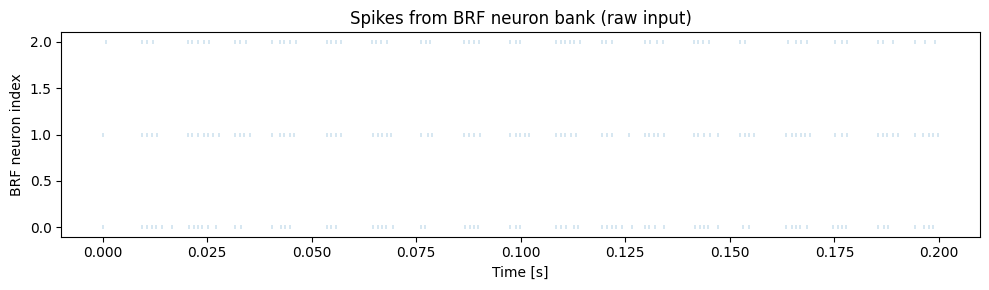

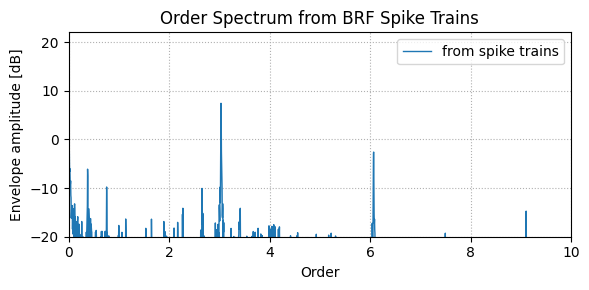

Total spikes: 794285 (1357.75 Hz) across 3 neurons, avg firing rate: 452.58 Hz, efficiency: 0.1657 spikes/sample (16.57%) in 585.00 s signal duration.


In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.signal import convolve
import seaborn as sns
import pandas as pd

from brf_lightning.data.bearing.utils import load_vibration_data

# -------------------------------
# Configuration
# -------------------------------
SHAFT_HZ    = 30.0                                    # shaft speed
DATA_FILE   = Path(f'data/bearing_thl_v1/fAII{int(SHAFT_HZ)}.csv')
ORDERS_OF_INTEREST = [3, 6, 9]                        # fault orders
fs = 8192                          # Sampling rate [Hz]

# Load data
df, fs = load_vibration_data(DATA_FILE)
x_raw = df["sensor_bearing"].values.astype(np.float32)

x_raw_norm = (x_raw - np.mean(x_raw)) / np.std(x_raw)  # Normalize input

# BRF neuron bank parameters
N_RESONATORS = 3
Q_FACTOR = 2
THRESHOLD = 0.9
REFRAC_MS = 1                      # Refractory period in milliseconds
BAND_LOW, BAND_HIGH = 1200, 2400  # Frequency band of interest [Hz]

# Envelope spectrum parameters
SMOOTH_MS = 2                     # Spike train smoothing width [ms]
NFFT_ENV = 65536                  # FFT length (zero-padding)
WINDOW_FN = np.hanning            # Window function for FFT
speed = SHAFT_HZ                        # Shaft rotation speed [Hz] for order calc

# -------------------------------
# BRF Neuron Bank (Spiking)
# -------------------------------
def brf_bank_output(x, fs, f0s, Qs, theta=0.2):
    """Simulates BRF neuron bank: complex bandpass filter followed by thresholding and refractory."""
    REFRAC_SAMPLES = int(fs * REFRAC_MS / 1000)
    n = len(x)
    spike_trains = []
    u_all = []
    for f0, Q in zip(f0s, Qs):
        r = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2 * np.pi * f0 / fs
        lam = r * np.exp(1j * ang)
        z = 0j
        spikes = np.zeros(n)
        u_trace = np.zeros(n)
        last_spike = -REFRAC_SAMPLES
        for i, sample in enumerate(x):
            if i - last_spike >= REFRAC_SAMPLES:
                z = lam * z + sample
                u = z.real
                u_trace[i] = u
                if u > theta:
                    spikes[i] = 1
                    last_spike = i
        spike_trains.append(spikes)
        u_all.append(u_trace)
    return np.array(spike_trains), np.array(u_all)

# Define center frequencies and Qs
f0s = np.linspace(BAND_LOW, BAND_HIGH, N_RESONATORS)
Qs = [Q_FACTOR] * N_RESONATORS

# Run BRF neuron bank
spikes_raw, u_all_raw = brf_bank_output(x_raw_norm, fs, f0s, Qs, theta=THRESHOLD)

# -------------------------------
# Spike Raster Plot
# ------------------------------- 
win = slice(0, int(0.2 * fs))  # First 0.2 seconds
time = np.arange(len(x_raw_norm)) / fs
spike_data = []
for i, spikes in enumerate(spikes_raw):
    spike_times = time[win][spikes[win] > 0.5]
    spike_data.extend([(tt, i) for tt in spike_times])
df_spike = pd.DataFrame(spike_data, columns=["time", "neuron"])

plt.figure(figsize=(10, 3))
sns.scatterplot(data=df_spike, x="time", y="neuron", s=10, marker="|")
plt.xlabel("Time [s]")
plt.ylabel("BRF neuron index")
plt.title("Spikes from BRF neuron bank (raw input)")
plt.tight_layout()
plt.show()

# -------------------------------
# Envelope via Smoothed Spike Trains
# -------------------------------
win_len = int(fs * SMOOTH_MS / 1000)
win_len = max(win_len, 3) | 1  # Ensure odd length
smoothing_kernel = np.ones(win_len) / win_len

smoothed = np.array([
    convolve(st, smoothing_kernel, mode="same")
    for st in spikes_raw
])
env_sum = smoothed.sum(axis=0)

# -------------------------------
# FFT-based Envelope Order Spectrum
# -------------------------------
env_win = env_sum * WINDOW_FN(len(env_sum))
spec = np.fft.rfft(env_win, n=NFFT_ENV)
spec_db = 20 * np.log10(np.abs(spec) + 1e-6)
freqs = np.fft.rfftfreq(NFFT_ENV, d=1/fs)
orders = freqs / speed

plt.figure(figsize=(6, 3))
plt.plot(orders, spec_db, lw=1.0, label="from spike trains")
plt.xlim(0, 10)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title("Order Spectrum from BRF Spike Trains")
plt.grid(ls=":")
plt.tight_layout()
plt.legend()
plt.show()

# -------------------------------
# Spike Statistics
# -------------------------------
total_spikes = int(np.sum(spikes_raw))
duration_sec = len(x_raw_norm) / fs
n_neurons = spikes_raw.shape[0]
avg_firing_rate = total_spikes / n_neurons / duration_sec
efficiency = total_spikes / len(x_raw_norm)

print(f"Total spikes: {total_spikes}"
      f" ({total_spikes / duration_sec:.2f} Hz)"
      f" across {n_neurons} neurons, "
      f"avg firing rate: {avg_firing_rate:.2f} Hz, "
      f"efficiency: {efficiency:.4f} spikes/sample"
      f" ({efficiency * 100:.2f}%)"
      f" in {duration_sec:.2f} s signal duration.")


In [9]:
import torch

from brf_snn.modules.rf import sustain_osc

def from_f0_Q(f0s: list[float], Q: float, fs: float = 8192):
    dt = 1 / fs
    omega = 2 * np.pi * torch.tensor(f0s) * dt
    b = -omega / (2 * Q)
    p_omega = sustain_osc(omega)
    b_offset = p_omega - b.abs()
    return omega, b_offset


from_f0_Q([1200, 1800, 2400], 2, fs=8192)

(tensor([0.9204, 1.3806, 1.8408]), tensor([-0.2343, -0.3547, -0.4771]))

Differing spike samples: 0.0 (expect 0)


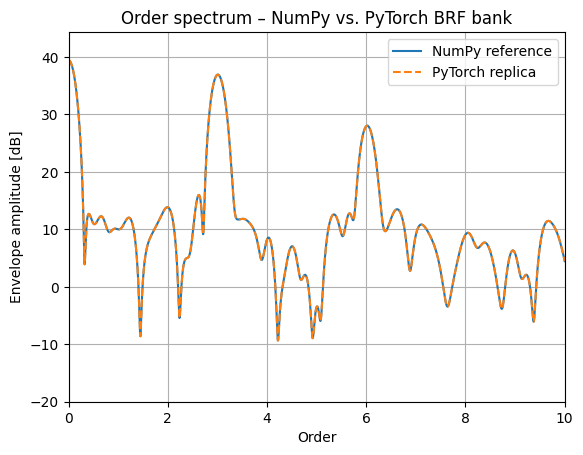

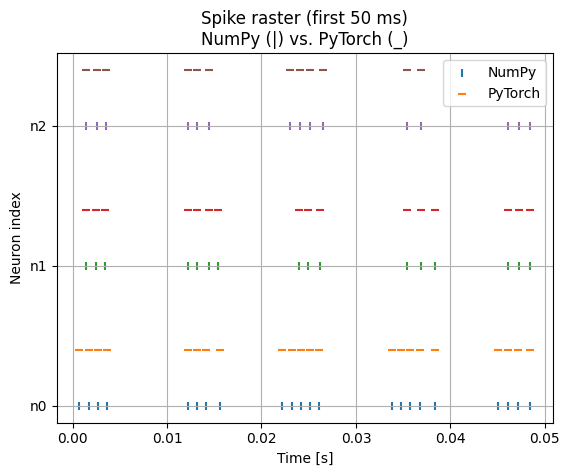

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.signal import convolve

# ------------------------------------------------------------------
# 1.  Minimal NumPy reference implementation (unchanged)
# ------------------------------------------------------------------
def brf_bank_output_numpy(x, fs, f0s, Qs, theta=0.9, refrac_ms=1.0):
    """Complex one–tap IIR followed by hard-refractory spiking (NumPy)."""
    refrac_samples = int(fs * refrac_ms / 1000.0)
    n = len(x)
    spikes = []
    for f0, Q in zip(f0s, Qs):
        r = np.exp(-np.pi * f0 / (Q * fs))
        ang = 2 * np.pi * f0 / fs
        lam = r * np.exp(1j * ang)

        z = 0j
        last_spike = -refrac_samples
        s = np.zeros(n, dtype=np.float32)
        for i, sample in enumerate(x):
            if i - last_spike >= refrac_samples:
                z = lam * z + sample
                if z.real > theta:
                    s[i] = 1.0
                    last_spike = i
        spikes.append(s)
    return np.array(spikes)


# ------------------------------------------------------------------
# 2.  Bit-identical PyTorch replica
# ------------------------------------------------------------------
@torch.no_grad()
def brf_bank_output_torch(x, fs, f0s, Qs, theta=0.9, refrac_ms=1.0):
    """Complex one–tap IIR followed by hard-refractory spiking (Torch)."""
    device = x.device
    T = x.numel()
    f0s = torch.as_tensor(f0s, dtype=x.dtype, device=device)
    Qs = torch.as_tensor(Qs, dtype=x.dtype, device=device)

    r = torch.exp(-torch.pi * f0s / (Qs * fs))
    ang = 2 * torch.pi * f0s / fs
    lam = r * torch.exp(1j * ang)

    N = f0s.numel()
    z = torch.zeros(N, dtype=torch.cfloat, device=device)
    refrac_samples = int(fs * refrac_ms / 1000.0)
    last_spike = torch.full((N,), -refrac_samples, dtype=torch.int64, device=device)
    spikes = torch.zeros(N, T, dtype=x.dtype, device=device)

    for t in range(T):
        ready = (t - last_spike) >= refrac_samples
        if ready.any():
            z[ready] = lam[ready] * z[ready] + x[t]
            fired = ready & (z.real > theta)
            if fired.any():
                spikes[fired, t] = 1.0
                last_spike[fired] = t
    return spikes.cpu().numpy()  # return on CPU for comparison


# ------------------------------------------------------------------
# 3.  Synthetic test signal (0.2 s) – replace with real trace if available
# ------------------------------------------------------------------
fs = 8192.0
duration = 0.2  # seconds
t = np.arange(int(duration * fs)) / fs
signal = 0.5 * np.sin(2 * np.pi * 90 * t)          # carrier-like component
signal += 0.1 * np.random.randn(t.size)            # broadband noise
signal = (signal - signal.mean()) / signal.std()   # z-normalise
x_torch = torch.from_numpy(signal.astype(np.float32))

# Resonator setup
N_RESONATORS = 3
f0s = np.linspace(1200, 2400, N_RESONATORS)
Qs  = [2.0] * N_RESONATORS

# ------------------------------------------------------------------
# 4.  Run both implementations
# ------------------------------------------------------------------
spk_np   = brf_bank_output_numpy(signal, fs, f0s, Qs)
spk_torch = brf_bank_output_torch(x_torch, fs, f0s, Qs)

# Verify equality
diff = np.abs(spk_np - spk_torch).sum()
print(f"Differing spike samples: {diff} (expect 0)")

# ------------------------------------------------------------------
# 5.  Envelope & order spectrum for each implementation
# ------------------------------------------------------------------
SMOOTH_MS = 2
win_len = int(fs * SMOOTH_MS / 1000)
win_len = max(win_len, 3) | 1  # ensure odd
kernel = np.ones(win_len) / win_len

def order_spectrum(spikes, fs, shaft_hz, nfft=65536):
    smoothed = np.array([convolve(s, kernel, mode="same") for s in spikes])
    env = smoothed.sum(axis=0)
    spec = np.fft.rfft(env * np.hanning(env.size), n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=1 / fs)
    orders = freqs / shaft_hz
    spec_db = 20 * np.log10(np.abs(spec) + 1e-6)
    return orders, spec_db

shaft_hz = 30.0
ord_np, spec_np = order_spectrum(spk_np,   fs, shaft_hz)
ord_pt, spec_pt = order_spectrum(spk_torch, fs, shaft_hz)

# ------------------------------------------------------------------
# 6.  Plot order spectra overlay (figure 1)
# ------------------------------------------------------------------
plt.figure()
plt.plot(ord_np, spec_np, label="NumPy reference")
plt.plot(ord_pt, spec_pt, linestyle="--", label="PyTorch replica")
plt.xlim(0, 10)
plt.ylim(bottom=-20)
plt.xlabel("Order")
plt.ylabel("Envelope amplitude [dB]")
plt.title("Order spectrum – NumPy vs. PyTorch BRF bank")
plt.legend()
plt.grid(True)

# ------------------------------------------------------------------
# 7.  Spike raster overlay for first 0.05 s (figure 2)
# ------------------------------------------------------------------
win = slice(0, int(0.05 * fs))
time = t[win]
plt.figure()
for idx in range(N_RESONATORS):
    y_np = np.full(spk_np.shape[1], idx)            # y-level per resonator
    y_pt = y_np + 0.4                               # offset for visibility
    plt.scatter(time[spk_np[idx, win] > 0.5], y_np[win][spk_np[idx, win] > 0.5],
                marker="|", s=30, label="NumPy" if idx == 0 else None)
    plt.scatter(time[spk_torch[idx, win] > 0.5], y_pt[win][spk_torch[idx, win] > 0.5],
                marker="_", s=30, label="PyTorch" if idx == 0 else None)
plt.yticks(range(N_RESONATORS), [f"n{n}" for n in range(N_RESONATORS)])
plt.xlabel("Time [s]")
plt.ylabel("Neuron index")
plt.title("Spike raster (first 50 ms)\nNumPy (|) vs. PyTorch (_)")
plt.legend(loc="upper right")
plt.grid(True)

plt.show()
